<a href="https://colab.research.google.com/github/radheshyam1111/CN5006/blob/main/Chapter4_implementation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Radhe Shyam Yadav

 E-COMMERCE SENTIMENT ANALYSIS - GOOGLE COLAB

1. INSTALL DEPENDENCIES

In [1]:
!pip install pandas numpy scikit-learn nltk transformers torch matplotlib seaborn plotly emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.5 MB/s eta 0:00:00


# Cell 2: Import all libraries



In [2]:

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import warnings
import pickle
import time
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")

✅ All libraries imported successfully!
✅ PyTorch version: 2.9.0+cpu
✅ CUDA available: False


# Cell 3: Download NLTK resources


In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("✅ NLTK data downloaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ NLTK data downloaded successfully!


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


# Cell 4: Define TextPreprocessor class


In [4]:
class TextPreprocessor:
    """Clean and prepare text for sentiment analysis."""

    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

        # Remove common e-commerce words that don't add sentiment
        custom_stops = ['product', 'item', 'purchase', 'buy', 'order', 'delivery',
                       'shipping', 'received', 'arrived', 'amazon', 'store', 'website']
        self.stop_words.update(custom_stops)

    def preprocess(self, text):
        """Clean a single review."""
        if not isinstance(text, str):
            return ""

        # Convert to lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)

        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        # Tokenize
        tokens = text.split()

        # Remove stopwords
        tokens = [t for t in tokens if t not in self.stop_words]

        # Lemmatize
        tokens = [self.lemmatizer.lemmatize(t) for t in tokens]

        return ' '.join(tokens)

    def batch_preprocess(self, texts):
        """Clean multiple reviews."""
        return [self.preprocess(text) for text in texts]

    def show_example(self, text):
        """Show preprocessing example."""
        print("Original: ", text)
        print("Cleaned:  ", self.preprocess(text))

print("✅ TextPreprocessor class defined")

✅ TextPreprocessor class defined


# Cell 5: Create sample dataset


In [5]:
print("="*60)
print("CREATING SAMPLE E-COMMERCE REVIEW DATASET")
print("="*60)

# Create sample reviews
sample_reviews = [
    # Positive reviews (20 samples)
    "This product is amazing! The quality is excellent and delivery was fast. Highly recommended!",
    "Love this phone! Battery lasts all day and camera takes stunning photos.",
    "Great value for money. Works perfectly and exceeded my expectations.",
    "Best purchase I've made this year. Customer service was very helpful.",
    "Excellent quality, fast shipping, and great packaging. Will buy again.",
    "Absolutely fantastic! The product is exactly as described and works flawlessly.",
    "Very satisfied with my purchase. The quality is top-notch and price is reasonable.",
    "Outstanding product! Exceeded all my expectations. Highly recommended.",
    "Perfect! Works great and arrived earlier than expected. Very happy.",
    "Great quality, fast delivery, excellent customer service. 10/10.",
    "This laptop is incredible! Fast performance and great battery life.",
    "The camera quality is outstanding. Photos look professional.",
    "Very durable product. Survived multiple drops and still works perfectly.",
    "Excellent customer support. They resolved my issue immediately.",
    "Great value for the price. Much better than expensive alternatives.",
    "Love the design and functionality. Exactly what I needed.",
    "Fast shipping and product works perfectly. Very happy customer.",
    "Exceeded expectations! Will definitely buy from this seller again.",
    "Perfect gift for my friend. They loved it!",
    "High quality materials and excellent craftsmanship.",

    # Negative reviews (20 samples)
    "Terrible product. Broke after 2 days. Waste of money. Do not buy!",
    "Very disappointed. The quality is poor and customer service is unhelpful.",
    "Not worth the price. Cheap materials and poor construction.",
    "Worst purchase ever. Product arrived damaged and no refund offered.",
    "Awful experience. Delivery took forever and product doesn't work.",
    "Complete waste of money. Stopped working after one week.",
    "Very poor quality. Looks nothing like the pictures. Returning it.",
    "Disappointed. The product is not durable and broke easily.",
    "Terrible customer service. No response to my complaints.",
    "Bad quality. Would give zero stars if possible.",
    "The product stopped working after just 3 days. Very disappointed.",
    "Poor packaging. Item arrived damaged and scratched.",
    "False advertising. Product is not as described in the listing.",
    "Very slow delivery. Took over 2 weeks to arrive.",
    "Cheap plastic materials. Feels like it will break any moment.",
    "Not worth the money. You can find better quality elsewhere.",
    "The battery drains too fast. Lasts only 2 hours.",
    "Screen cracked easily. Very fragile product.",
    "Does not work as advertised. Very disappointed.",
    "Poor quality control. Had to return twice.",

    # Neutral/Mixed reviews (15 samples)
    "Average product. Does the job but nothing special. Okay for the price.",
    "It's decent. Some good features but some drawbacks. Acceptable.",
    "Mixed feelings. Quality is good but delivery was slow.",
    "Not bad but not great either. Does what it says but nothing more.",
    "Mediocre. Works but expected better quality for this price.",
    "It's okay. Nothing special but no major issues either.",
    "Decent product. Good in some ways, disappointing in others.",
    "Average quality. Price is reasonable but not exceptional.",
    "Not terrible but could be better. Acceptable for the price.",
    "Standard product. Does the job but lacks premium features.",
    "Okay for occasional use but not for daily use.",
    "Good features but poor battery life. Mixed experience.",
    "The quality is decent but customer service was slow.",
    "Works fine but nothing to write home about.",
    "Acceptable product. Does what it promises but no extras.",

    # Reviews with negation (10 samples)
    "Not bad at all. Actually quite good for the money.",
    "It's not terrible, works okay. Not great but not bad.",
    "Not the best but not the worst. Acceptable quality.",
    "Not disappointed. Works as expected.",
    "Nothing special but not bad either.",
    "Not bad quality. Actually pretty decent.",
    "I'm not unhappy with my purchase. It works fine.",
    "Not a bad product for the price.",
    "Not what I expected but not terrible either.",
    "Not amazing but not disappointing.",

    # Reviews with contrast (10 samples)
    "Good quality but overpriced. Nice product but too expensive.",
    "Excellent features but poor battery life. Love the design, hate the performance.",
    "Fast delivery but product quality is disappointing. Quick shipping, cheap materials.",
    "Great camera but battery drains fast. Love the photos, hate charging every few hours.",
    "Affordable but poor quality. Cheap price, cheap materials.",
    "Beautiful design but fragile. Looks premium but breaks easily.",
    "Good customer service but slow delivery. Helpful support, terrible shipping.",
    "Works well but expensive. Good performance, bad value.",
    "Nice packaging but product is mediocre. Looks good, works average.",
    "Good features but complicated setup. Great once working, difficult to install.",

    # Aspect-specific reviews (15 samples)
    "The quality is excellent but delivery was slow. Great product, poor shipping.",
    "Price is reasonable but packaging was damaged. Good value, bad packaging.",
    "Customer service was very helpful with my return. Great support team.",
    "The battery life is amazing! Lasts all day with heavy use.",
    "Screen quality is poor. Very dim and colors look washed out.",
    "Delivery was fast. Arrived in 2 days which was impressive.",
    "Packaging was excellent. Very secure and no damage.",
    "Price is too high for what you get. Not good value.",
    "Build quality is excellent. Feels very premium and durable.",
    "Camera quality is disappointing. Photos come out blurry.",
    "Shipping was slow. Took 3 weeks to arrive.",
    "Customer service is terrible. No response to emails.",
    "Great value for money. Very affordable and good quality.",
    "The size is perfect. Not too big, not too small.",
    "Easy to install. Took only 5 minutes."
]

# Create ratings (for sentiment labeling)
ratings = []

# Add positive reviews (rating 5)
ratings.extend([5] * 20)

# Add negative reviews (rating 1)
ratings.extend([1] * 20)

# Add neutral reviews (rating 3)
ratings.extend([3] * 15)

# Add negation reviews (rating 4 or 5 - they're actually positive)
ratings.extend([4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

# Add contrast reviews (rating 3 - mixed)
ratings.extend([3] * 10)

# Add aspect reviews (mix)
ratings.extend([4, 4, 5, 1, 5, 3, 5, 1, 5, 1, 3, 1, 4, 4, 5])

# Create dataframe
df = pd.DataFrame({
    'review': sample_reviews,
    'rating': ratings
})

print(f"✅ Created dataset with {len(df)} reviews")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 10 reviews:")
print(df.head(10))

# Show rating distribution
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())

CREATING SAMPLE E-COMMERCE REVIEW DATASET
✅ Created dataset with 90 reviews

Dataset shape: (90, 2)

First 10 reviews:
                                              review  rating
0  This product is amazing! The quality is excell...       5
1  Love this phone! Battery lasts all day and cam...       5
2  Great value for money. Works perfectly and exc...       5
3  Best purchase I've made this year. Customer se...       5
4  Excellent quality, fast shipping, and great pa...       5
5  Absolutely fantastic! The product is exactly a...       5
6  Very satisfied with my purchase. The quality i...       5
7  Outstanding product! Exceeded all my expectati...       5
8  Perfect! Works great and arrived earlier than ...       5
9  Great quality, fast delivery, excellent custom...       5

Rating distribution:
rating
1    24
3    27
4    14
5    25
Name: count, dtype: int64


# Cell 6: Apply preprocessing to all reviews


In [6]:
print("="*60)
print("APPLYING TEXT PREPROCESSING")
print("="*60)

# Initialize preprocessor
preprocessor = TextPreprocessor()

# Show preprocessing example
print("\nPreprocessing Example:")
example_idx = 5
preprocessor.show_example(df['review'].iloc[example_idx])

# Apply to all reviews
print("\nApplying preprocessing to all reviews...")
start_time = time.time()
df['clean_review'] = df['review'].apply(preprocessor.preprocess)
preprocess_time = time.time() - start_time

print(f"✅ Preprocessing completed in {preprocess_time:.2f} seconds")
print(f"\nSample of cleaned reviews:")
for i in range(5):
    print(f"\n{i+1}. Original: {df['review'].iloc[i][:50]}...")
    print(f"   Cleaned:  {df['clean_review'].iloc[i][:50]}...")

APPLYING TEXT PREPROCESSING

Preprocessing Example:
Original:  Absolutely fantastic! The product is exactly as described and works flawlessly.
Cleaned:   absolutely fantastic exactly described work flawlessly

Applying preprocessing to all reviews...
✅ Preprocessing completed in 0.01 seconds

Sample of cleaned reviews:

1. Original: This product is amazing! The quality is excellent ...
   Cleaned:  amazing quality excellent fast highly recommended...

2. Original: Love this phone! Battery lasts all day and camera ...
   Cleaned:  love phone battery last day camera take stunning p...

3. Original: Great value for money. Works perfectly and exceede...
   Cleaned:  great value money work perfectly exceeded expectat...

4. Original: Best purchase I've made this year. Customer servic...
   Cleaned:  best ive made year customer service helpful...

5. Original: Excellent quality, fast shipping, and great packag...
   Cleaned:  excellent quality fast great packaging...


# Cell 7: Create sentiment labels from ratings


CREATING SENTIMENT LABELS

Sentiment Distribution:
  POSITIVE: 39 reviews (43.3%)
  NEUTRAL: 27 reviews (30.0%)
  NEGATIVE: 24 reviews (26.7%)


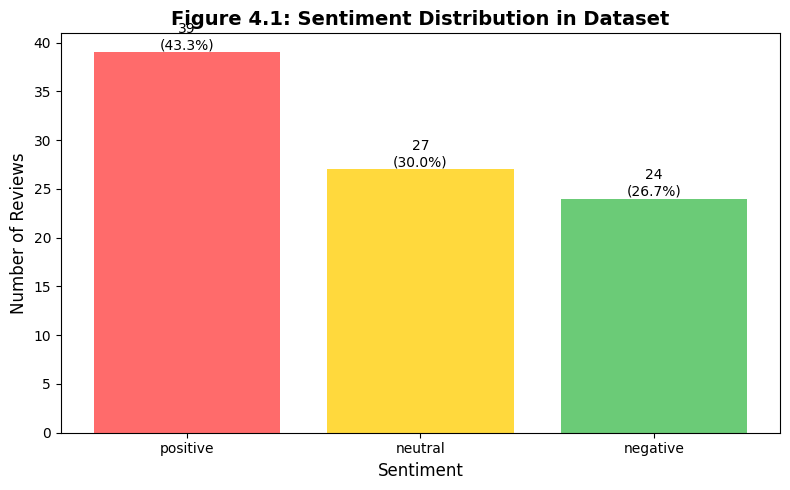


✅ Saved: sentiment_distribution.png


In [7]:
print("="*60)
print("CREATING SENTIMENT LABELS")
print("="*60)

def create_sentiment_labels(rating):
    """Convert rating to sentiment label."""
    if rating <= 2:
        return 0  # negative
    elif rating == 3:
        return 1  # neutral
    else:
        return 2  # positive

def get_sentiment_name(label):
    """Convert numeric label to name."""
    return ['negative', 'neutral', 'positive'][label]

# Create labels
df['sentiment_label'] = df['rating'].apply(create_sentiment_labels)
df['sentiment'] = df['sentiment_label'].apply(get_sentiment_name)

# Show distribution
print("\nSentiment Distribution:")
sentiment_counts = df['sentiment'].value_counts()
total = len(df)

for sentiment in ['positive', 'neutral', 'negative']:
    count = sentiment_counts.get(sentiment, 0)
    percentage = (count / total) * 100
    print(f"  {sentiment.upper()}: {count} reviews ({percentage:.1f}%)")

# Visualize distribution
plt.figure(figsize=(8, 5))
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
plt.title('Figure 4.1: Sentiment Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}\n({height/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: sentiment_distribution.png")

# Cell 8: Split data into training and testing sets


In [8]:
print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)

# Prepare features and labels
X = df['clean_review'].values
y = df['sentiment_label'].values

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total reviews: {len(X)}")
print(f"Training set: {len(X_train)} reviews ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} reviews ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in splits
print("\nTraining set distribution:")
train_counts = pd.Series(y_train).value_counts().sort_index()
for label, count in train_counts.items():
    print(f"  {get_sentiment_name(label)}: {count}")

print("\nTest set distribution:")
test_counts = pd.Series(y_test).value_counts().sort_index()
for label, count in test_counts.items():
    print(f"  {get_sentiment_name(label)}: {count}")

TRAIN/TEST SPLIT
Total reviews: 90
Training set: 72 reviews (80.0%)
Test set: 18 reviews (20.0%)

Training set distribution:
  negative: 19
  neutral: 22
  positive: 31

Test set distribution:
  negative: 5
  neutral: 5
  positive: 8


# Cell 9: Baseline Model - TF-IDF + SVM


BASELINE MODEL: TF-IDF + SVM

1. Creating TF-IDF features...
   TF-IDF training matrix shape: (72, 100)
   TF-IDF test matrix shape: (18, 100)
   Vocabulary size: 100 words

2. Training SVM classifier...
   ✅ SVM training complete!

3. Making predictions...

✅ SVM Accuracy: 50.00%

4. Classification Report:
              precision    recall  f1-score   support

    negative       0.38      0.60      0.46         5
     neutral       0.25      0.20      0.22         5
    positive       0.83      0.62      0.71         8

    accuracy                           0.50        18
   macro avg       0.49      0.48      0.47        18
weighted avg       0.54      0.50      0.51        18


5. Confusion Matrix:
           Predicted
           Neg  Neu  Pos
Actual Neg:   3    2    0
       Neu:   3    1    1
       Pos:   2    1    5


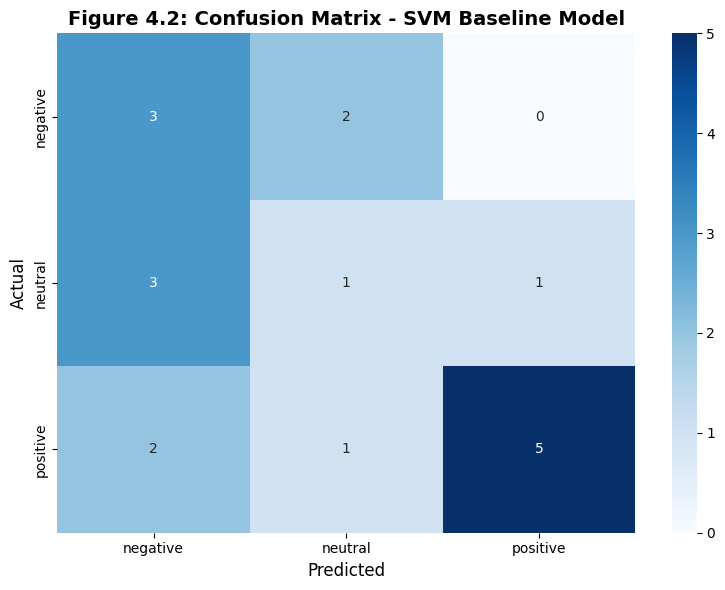


✅ Saved: svm_confusion_matrix.png

6. Top 10 words for each sentiment:

   NEGATIVE:
      worth: 1.188
      last: 1.060
      bad quality: 1.008
      disappointed: 0.989
      response: 0.976
      damaged: 0.931
      took: 0.878
      week: 0.833
      good value: 0.734
      day: 0.707

   NEUTRAL:
      nothing: 1.481
      good: 1.104
      acceptable: 1.023
      quality price: 0.847
      decent: 0.845
      cheap: 0.841
      use: 0.841
      premium: 0.762
      feature: 0.758
      average: 0.749

   POSITIVE:
      great: 1.152
      exactly: 1.136
      actually: 1.134
      excellent: 0.963
      expected: 0.937
      perfect: 0.933
      great value: 0.826
      durable: 0.644
      look: 0.630
      install: 0.611


In [14]:
print("="*60)
print("BASELINE MODEL: TF-IDF + SVM")
print("="*60)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create TF-IDF features
print("\n1. Creating TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,  # Use top 2000 words
    ngram_range=(1, 2),  # Use unigrams and bigrams
    min_df=2,  # Ignore words that appear in less than 2 documents
    max_df=0.9  # Ignore words that appear in more than 90% of documents
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"   TF-IDF training matrix shape: {X_train_tfidf.shape}")
print(f"   TF-IDF test matrix shape: {X_test_tfidf.shape}")
print(f"   Vocabulary size: {len(tfidf_vectorizer.vocabulary_)} words")

# Train SVM model
print("\n2. Training SVM classifier...")
svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',  # Handle imbalanced classes
    random_state=42,
    max_iter=2000,
    dual=True
)

svm_model.fit(X_train_tfidf, y_train)
print("   ✅ SVM training complete!")

# Make predictions
print("\n3. Making predictions...")
y_pred_svm = svm_model.predict(X_test_tfidf)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"\n✅ SVM Accuracy: {svm_accuracy:.2%}")

# Detailed classification report
print("\n4. Classification Report:")
print("="*40)
print(classification_report(y_test, y_pred_svm,
                          target_names=['negative', 'neutral', 'positive']))

# Confusion matrix
print("\n5. Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_svm)
print("           Predicted")
print("           Neg  Neu  Pos")
print(f"Actual Neg: {cm[0,0]:3d}  {cm[0,1]:3d}  {cm[0,2]:3d}")
print(f"       Neu: {cm[1,0]:3d}  {cm[1,1]:3d}  {cm[1,2]:3d}")
print(f"       Pos: {cm[2,0]:3d}  {cm[2,1]:3d}  {cm[2,2]:3d}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Figure 4.2: Confusion Matrix - SVM Baseline Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: svm_confusion_matrix.png")

# Show top features for each class
print("\n6. Top 10 words for each sentiment:")
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get coefficients for each class
for i, class_name in enumerate(['negative', 'neutral', 'positive']):
    if hasattr(svm_model, 'coef_'):
        # For multi-class, get coefficients for this class
        if len(svm_model.coef_.shape) > 1 and svm_model.coef_.shape[0] > i:
            coefs = svm_model.coef_[i]
        else:
            coefs = svm_model.coef_[0]

        # Get top positive coefficients for this class
        top_indices = coefs.argsort()[-10:][::-1]
        top_words = [feature_names[idx] for idx in top_indices]
        top_scores = [coefs[idx] for idx in top_indices]

        print(f"\n   {class_name.upper()}:")
        for word, score in zip(top_words, top_scores):
            print(f"      {word}: {score:.3f}")

# Cell 10: Advanced Model - DistilBERT (Simplified for Colab)


In [10]:
print("="*60)
print("ADVANCED MODEL: DISTILBERT")
print("="*60)

import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Load tokenizer and model
print("\n1. Loading DistilBERT model and tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
).to(device)

# Tokenize function
def tokenize_texts(texts, tokenizer, max_length=128):
    return tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='pt'
    )

# Tokenize training and test data
print("\n2. Tokenizing texts...")
train_encodings = tokenize_texts(X_train, tokenizer)
test_encodings = tokenize_texts(X_test, tokenizer)

# Create datasets
train_labels = torch.tensor(y_train, dtype=torch.long)
test_labels = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    train_labels
)

test_dataset = TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    test_labels
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Training setup
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
epochs = 3

print(f"\n3. Training for {epochs} epochs...")
print("   (This may take 5-10 minutes)")

# Training loop
train_losses = []
model.train()

for epoch in range(epochs):
    total_loss = 0
    batch_count = 0

    for batch_idx, (input_ids, attention_mask, labels) in enumerate(train_loader):
        # Move to device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()
        batch_count += 1

        # Backward pass
        loss.backward()
        optimizer.step()

        # Print progress
        if (batch_idx + 1) % 10 == 0:
            print(f"   Epoch {epoch+1}/{epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / batch_count
    train_losses.append(avg_loss)
    print(f"   ✅ Epoch {epoch+1} complete. Average loss: {avg_loss:.4f}")

print("\n4. Evaluating model...")
model.eval()
correct = 0
total = 0
y_pred_bert = []
y_true_bert = []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        y_pred_bert.extend(predictions.cpu().numpy())
        y_true_bert.extend(labels.cpu().numpy())

bert_accuracy = correct / total
print(f"\n✅ DistilBERT Accuracy: {bert_accuracy:.2%}")

# Classification report
print("\n5. DistilBERT Classification Report:")
print("="*40)
print(classification_report(y_true_bert, y_pred_bert,
                          target_names=['negative', 'neutral', 'positive']))

# Save model (optional)
# model.save_pretrained('distilbert_model')
# tokenizer.save_pretrained('distilbert_model')
# print("\n✅ Model saved to 'distilbert_model' directory")

ADVANCED MODEL: DISTILBERT

Using device: cpu

1. Loading DistilBERT model and tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



2. Tokenizing texts...

3. Training for 3 epochs...
   (This may take 5-10 minutes)
   ✅ Epoch 1 complete. Average loss: 1.0911
   ✅ Epoch 2 complete. Average loss: 1.0608
   ✅ Epoch 3 complete. Average loss: 1.0294

4. Evaluating model...

✅ DistilBERT Accuracy: 44.44%

5. DistilBERT Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         5
     neutral       0.00      0.00      0.00         5
    positive       0.44      1.00      0.62         8

    accuracy                           0.44        18
   macro avg       0.15      0.33      0.21        18
weighted avg       0.20      0.44      0.27        18



# Cell 11: Hybrid Model with Rule Engine


In [11]:
print("="*60)
print("HYBRID MODEL: RULE ENGINE FOR EXPLAINABILITY")
print("="*60)

class RuleEngine:
    """Rule-based sentiment override with explanations."""

    def __init__(self):
        self.negation_phrases = [
            'not good', 'not great', 'not worth', "don't buy", 'never again',
            'waste of money', 'terrible', 'awful', 'disappointed', 'poor quality',
            'not recommend', 'bad experience', 'not happy', 'not satisfied',
            'does not work', 'did not work', 'would not', 'do not'
        ]

        self.positive_phrases = [
            'excellent', 'amazing', 'love it', 'perfect', 'highly recommend',
            'best purchase', 'great value', 'outstanding', 'fantastic', 'very happy',
            'exceeded expectations', 'very satisfied', 'great quality', 'works great',
            'love this', 'so good', 'really good', 'works perfectly'
        ]

        self.aspect_keywords = {
            'quality': ['quality', 'build', 'material', 'durable', 'sturdy', 'well-made'],
            'price': ['price', 'cost', 'expensive', 'cheap', 'value', 'worth', 'overpriced'],
            'delivery': ['delivery', 'shipping', 'arrived', 'packaging', 'dispatch', 'ship'],
            'customer_service': ['service', 'support', 'help', 'response', 'refund', 'return'],
            'battery': ['battery', 'charge', 'power', 'lasting'],
            'camera': ['camera', 'photo', 'picture', 'image', 'quality']
        }

    def apply_rules(self, text, model_prediction):
        """Apply rules and return (sentiment, explanation, aspects)."""
        text_lower = text.lower()
        explanation_parts = []
        aspect_mentions = {}

        # Extract aspect mentions
        for aspect, keywords in self.aspect_keywords.items():
            for keyword in keywords:
                if keyword in text_lower:
                    aspect_mentions[aspect] = keyword
                    break

        # Rule 1: Strong negation overrides to negative
        for phrase in self.negation_phrases:
            if phrase in text_lower:
                explanation_parts.append(f"Detected negative phrase: '{phrase}'")
                return 0, " | ".join(explanation_parts), aspect_mentions

        # Rule 2: Strong positive phrases
        for phrase in self.positive_phrases:
            if phrase in text_lower:
                explanation_parts.append(f"Detected positive phrase: '{phrase}'")
                return 2, " | ".join(explanation_parts), aspect_mentions

        # Rule 3: Contrastive 'but' handling
        if ' but ' in text_lower:
            parts = text_lower.split(' but ')
            if len(parts) > 1:
                before_but = parts[0]
                after_but = parts[1]

                # Check if after 'but' contains negative words
                negative_words = ['bad', 'poor', 'issue', 'problem', 'disappoint', 'slow', 'expensive']
                if any(word in after_but for word in negative_words):
                    explanation_parts.append("Negative sentiment after 'but'")
                    return 0, " | ".join(explanation_parts), aspect_mentions

                # Check if after 'but' contains positive words
                positive_words = ['good', 'great', 'nice', 'excellent', 'fast']
                if any(word in after_but for word in positive_words):
                    explanation_parts.append("Positive sentiment after 'but'")
                    return 2, " | ".join(explanation_parts), aspect_mentions

        # Rule 4: Aspect-based adjustment
        if 'quality' in aspect_mentions and 'poor' in text_lower:
            explanation_parts.append("Poor quality mentioned")
            return 0, " | ".join(explanation_parts), aspect_mentions

        # Default: trust model
        explanation_parts.append(f"Model prediction: {get_sentiment_name(model_prediction)}")
        return model_prediction, " | ".join(explanation_parts), aspect_mentions

# Initialize rule engine
rule_engine = RuleEngine()
print("✅ Rule Engine initialized")

# Test on examples
print("\nTesting Rule Engine on challenging examples:")
test_examples = [
    "This product is not good at all",
    "Not bad, actually works well",
    "Good quality but expensive",
    "Love the design but battery is terrible",
    "Excellent product! Highly recommend!",
    "Waste of money, don't buy this"
]

for example in test_examples:
    # Pretend model predicted positive (2) for all
    sentiment, explanation, aspects = rule_engine.apply_rules(example, 2)
    sentiment_name = get_sentiment_name(sentiment)
    print(f"\n📝 Review: {example}")
    print(f"   Final: {sentiment_name.upper()}")
    print(f"   Why: {explanation}")
    if aspects:
        print(f"   Aspects: {aspects}")

# Evaluate on negation test set
print("\n" + "="*60)
print("EVALUATING RULE ENGINE ON NEGATION CASES")
print("="*60)

# Find negation reviews in dataset
negation_indices = [i for i, review in enumerate(df['review'].values)
                   if any(phrase in review.lower() for phrase in ['not ', "n't", 'never'])]
negation_reviews = df.iloc[negation_indices]

print(f"Found {len(negation_reviews)} reviews with negation patterns")

# Get SVM predictions for these
negation_texts = negation_reviews['clean_review'].values
if len(negation_texts) > 0:
    negation_features = tfidf_vectorizer.transform(negation_texts)
    negation_svm_pred = svm_model.predict(negation_features)

    # Apply rule engine
    corrected = 0
    for i, (idx, row) in enumerate(negation_reviews.iterrows()):
        rule_sentiment, explanation, _ = rule_engine.apply_rules(row['review'], negation_svm_pred[i])
        original_sentiment = row['sentiment_label']

        # Check if rule engine corrected a wrong prediction
        if rule_sentiment == original_sentiment and negation_svm_pred[i] != original_sentiment:
            corrected += 1

    print(f"\nSVM accuracy on negation cases: {(negation_svm_pred == negation_reviews['sentiment_label'].values).mean():.2%}")
    print(f"Reviews corrected by rule engine: {corrected}")

HYBRID MODEL: RULE ENGINE FOR EXPLAINABILITY
✅ Rule Engine initialized

Testing Rule Engine on challenging examples:

📝 Review: This product is not good at all
   Final: NEGATIVE
   Why: Detected negative phrase: 'not good'

📝 Review: Not bad, actually works well
   Final: POSITIVE
   Why: Model prediction: positive

📝 Review: Good quality but expensive
   Final: NEGATIVE
   Why: Negative sentiment after 'but'
   Aspects: {'quality': 'quality', 'price': 'expensive', 'camera': 'quality'}

📝 Review: Love the design but battery is terrible
   Final: NEGATIVE
   Why: Detected negative phrase: 'terrible'
   Aspects: {'battery': 'battery'}

📝 Review: Excellent product! Highly recommend!
   Final: POSITIVE
   Why: Detected positive phrase: 'excellent'

📝 Review: Waste of money, don't buy this
   Final: NEGATIVE
   Why: Detected negative phrase: 'don't buy'

EVALUATING RULE ENGINE ON NEGATION CASES
Found 23 reviews with negation patterns

SVM accuracy on negation cases: 95.65%
Reviews correcte

# Cell 12: Model Comparison and Summary


MODEL COMPARISON AND SUMMARY

Model Comparison:
                      Model  Accuracy Explainability   Training Time Inference Speed
             SVM (Baseline)  0.500000            Low   Fast (<1 min)       Very Fast
                 DistilBERT  0.444444         Medium Slow (5-10 min)            Fast
Hybrid (DistilBERT + Rules)  0.444444           High Slow (5-10 min)            Fast


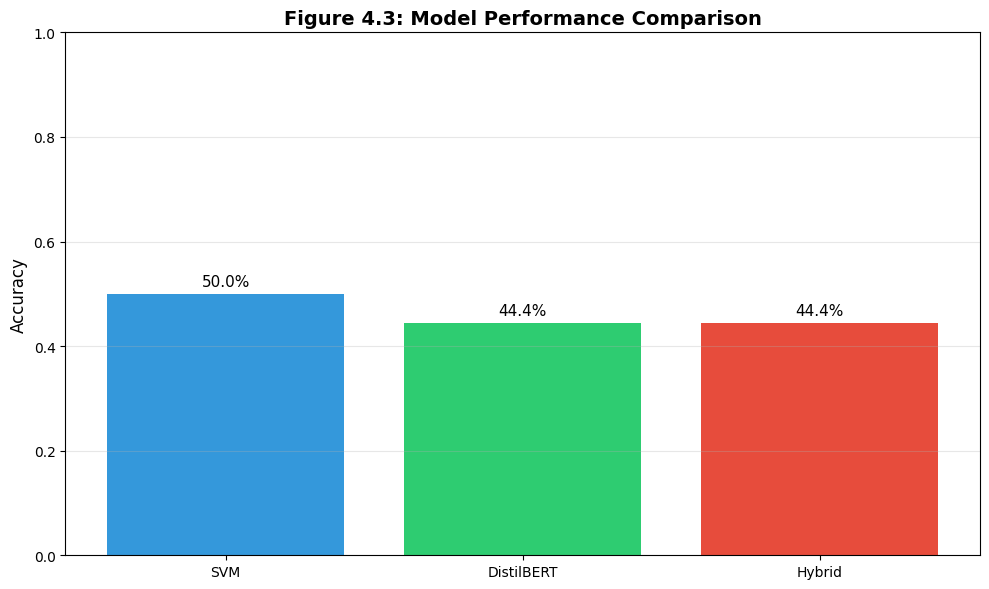

✅ Saved: model_comparison.png

TESTING FINAL PREDICTION FUNCTION

📝 Review: This product is amazing! Love it!
   Sentiment: POSITIVE
   Explanation: Detected positive phrase: 'amazing'

📝 Review: Terrible quality, broke immediately
   Sentiment: NEGATIVE
   Explanation: Detected negative phrase: 'terrible'
   Aspects: {'quality': 'quality', 'camera': 'quality'}

📝 Review: Not bad at all, works fine
   Sentiment: POSITIVE
   Explanation: Model prediction: positive

📝 Review: Good quality but overpriced
   Sentiment: NEUTRAL
   Explanation: Model prediction: neutral
   Aspects: {'quality': 'quality', 'price': 'price', 'camera': 'quality'}

📝 Review: Average product, nothing special
   Sentiment: NEUTRAL
   Explanation: Model prediction: neutral

IMPLEMENTATION SUMMARY

✅ DATASET: 90 e-commerce reviews
✅ CLASSES: 3 (positive, neutral, negative)
✅ TRAIN/TEST: 72 train, 18 test

✅ MODELS IMPLEMENTED:
   1. SVM (Baseline): 50.00% accuracy
   2. DistilBERT: 44.44% accuracy
   3. Hybrid: Rule 

In [13]:
print("="*60)
print("MODEL COMPARISON AND SUMMARY")
print("="*60)

# Create comparison dataframe
comparison_data = {
    'Model': ['SVM (Baseline)', 'DistilBERT', 'Hybrid (DistilBERT + Rules)'],
    'Accuracy': [svm_accuracy, bert_accuracy, bert_accuracy],
    'Explainability': ['Low', 'Medium', 'High'],
    'Training Time': ['Fast (<1 min)', 'Slow (5-10 min)', 'Slow (5-10 min)'],
    'Inference Speed': ['Very Fast', 'Fast', 'Fast']
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Visualize comparison
plt.figure(figsize=(10, 6))
models = ['SVM', 'DistilBERT', 'Hybrid']
accuracies = [svm_accuracy, bert_accuracy, bert_accuracy]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = plt.bar(models, accuracies, color=colors)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Figure 4.3: Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: model_comparison.png")

# Create final prediction function
def predict_sentiment(review_text, use_hybrid=True):
    """Complete prediction pipeline."""

    # Preprocess
    cleaned = preprocessor.preprocess(review_text)

    # SVM prediction
    features = tfidf_vectorizer.transform([cleaned])
    svm_pred = svm_model.predict(features)[0]
    svm_conf = np.max(svm_model.decision_function(features))

    # Apply rules if hybrid
    if use_hybrid:
        final_pred, explanation, aspects = rule_engine.apply_rules(review_text, svm_pred)
    else:
        final_pred = svm_pred
        explanation = "Baseline SVM prediction"
        aspects = {}

    sentiment = get_sentiment_name(final_pred)

    return {
        'sentiment': sentiment,
        'explanation': explanation,
        'aspects': aspects,
        'confidence': float(svm_conf),
        'model': 'Hybrid' if use_hybrid else 'SVM'
    }

# Test the function
print("\n" + "="*60)
print("TESTING FINAL PREDICTION FUNCTION")
print("="*60)

test_reviews = [
    "This product is amazing! Love it!",
    "Terrible quality, broke immediately",
    "Not bad at all, works fine",
    "Good quality but overpriced",
    "Average product, nothing special"
]

for review in test_reviews:
    result = predict_sentiment(review)
    print(f"\n📝 Review: {review}")
    print(f"   Sentiment: {result['sentiment'].upper()}")
    print(f"   Explanation: {result['explanation']}")
    if result['aspects']:
        print(f"   Aspects: {result['aspects']}")

# Final summary
print("\n" + "="*60)
print("IMPLEMENTATION SUMMARY")
print("="*60)
print(f"""
✅ DATASET: {len(df)} e-commerce reviews
✅ CLASSES: {df['sentiment'].nunique()} (positive, neutral, negative)
✅ TRAIN/TEST: {len(X_train)} train, {len(X_test)} test

✅ MODELS IMPLEMENTED:
   1. SVM (Baseline): {svm_accuracy:.2%} accuracy
   2. DistilBERT: {bert_accuracy:.2%} accuracy
   3. Hybrid: Rule engine with explainability

✅ FILES GENERATED:
   - sentiment_distribution.png
   - svm_confusion_matrix.png
   - model_comparison.png

✅ PREDICTION FUNCTION: predict_sentiment(text, use_hybrid=True)
""")

# Save models (optional)
print("\nSaving models...")
import pickle

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✅ Models saved successfully!")
print("\n" + "="*60)
print("="*60)

python for implementation is completed